In [21]:
import pandas as pd
data = pd.read_csv("../course_assignments/homework8/state_data.csv")
print(data.shape) #4 columns and 51 rows 
print(data.head(4))
print(data.tail(4))
#the columns represent the abreviation of the state, latitude, longitude, full name 
#the first state is alaska, the last is wyoming
#there are 52 entries, because DC and peurto rico were both included 
med_lat = data["latitude"].median() #39.4
med_lon = data["longitude"].median() #-89.1
data["lat_distance"] = abs(data["latitude"] - med_lat)
data["lon_distance"] = abs(data["longitude"] - med_lon)
print(data.shape) #now there are 52 rows with 6 columns 
closest_lat = data.sort_values("lat_distance").iloc[0]
farthest_lat = data.sort_values("lat_distance").iloc[-1]
closest_lon = data.sort_values("lon_distance").iloc[0]
farthest_lon = data.sort_values("lon_distance").iloc[-1]
print(f"Closest to median latitude : {closest_lat['state']} by {closest_lat['lat_distance']:.2f}")
print(f"Farthest from median latitude : {farthest_lat['state']} by {farthest_lat['lat_distance']:.2f}")
print(f"Closest to median longitude : {closest_lon['state']} by {closest_lon['lat_distance']:.2f}")
print(f"Farthest from median longitude : {farthest_lon['state']} by {farthest_lon['lat_distance']:.2f}")
#style.set_table_styles() is a function that is creating a table and altering the style of it 
#I found it in the user guide under table visualization 
#it is helpful to make the data more clear ans presentable 
data.style.set_table_styles()

(52, 4)
  state   latitude   longitude      name
0    AK  63.588753 -154.493062    Alaska
1    AL  32.318231  -86.902298   Alabama
2    AR  35.201050  -91.831833  Arkansas
3    AZ  34.048928 -111.093731   Arizona
   state   latitude   longitude           name
48    WA  47.751074 -120.740139     Washington
49    WI  43.784440  -88.787868      Wisconsin
50    WV  38.597626  -80.454903  West Virginia
51    WY  43.075968 -107.290284        Wyoming
(52, 6)
Closest to median latitude : CO by 0.11
Farthest from median latitude : AK by 24.15
Closest to median longitude : MS by 7.08
Farthest from median longitude : HI by 19.54


,state,latitude,longitude,name,lat_distance,lon_distance
0,AK,63.588753,-154.493062,Alaska,24.153237,65.399864
1,AL,32.318231,-86.902298,Alabama,7.117285,2.190900
2,AR,35.201050,-91.831833,Arkansas,4.234465,2.738635
3,AZ,34.048928,-111.093731,Arizona,5.386588,22.000533
4,CA,36.778261,-119.417932,California,2.657255,30.324734
5,CO,39.550051,-105.782067,Colorado,0.114536,16.688869
6,CT,41.603221,-73.087749,Connecticut,2.167705,16.005449
7,DC,38.905985,-77.033418,District of Columbia,0.529530,12.059780
8,DE,38.910832,-75.527670,Delaware,0.524684,13.565528
9,FL,27.664827,-81.515754,Florida,11.770689,7.577444


               method  number  orbital_period   mass  distance  year
0     Radial Velocity       1      269.300000   7.10     77.40  2006
1     Radial Velocity       1      874.774000   2.21     56.95  2008
2     Radial Velocity       1      763.000000   2.60     19.84  2011
3     Radial Velocity       1      326.030000  19.40    110.62  2007
4     Radial Velocity       1      516.220000  10.50    119.47  2009
...               ...     ...             ...    ...       ...   ...
1030          Transit       1        3.941507    NaN    172.00  2006
1031          Transit       1        2.615864    NaN    148.00  2007
1032          Transit       1        3.191524    NaN    174.00  2007
1033          Transit       1        4.125083    NaN    293.00  2008
1034          Transit       1        4.187757    NaN    260.00  2008

[1035 rows x 6 columns]
               method  number  year
0     Radial Velocity       1  2006
1     Radial Velocity       1  2008
2     Radial Velocity       1  2011
3  

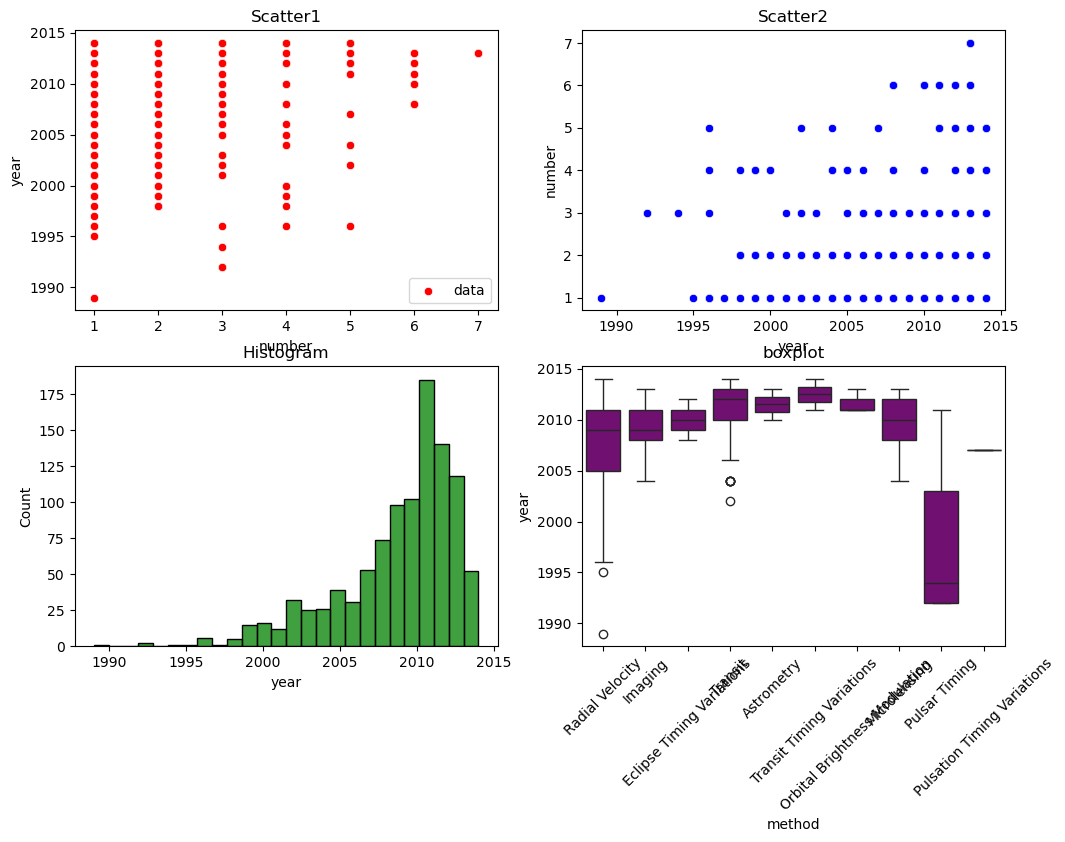

In [41]:
import matplotlib.pyplot as plt 
import seaborn as sns 
df = sns.load_dataset("planets")
print(df)
df = df.dropna(axis = 1)
print(df)
#the data has 1053 rows and 3 columns 
print(df.head(4))
print(df.tail(4))
#the first column is the method, the second is the number, and the third is the year
fig, axes = plt.subplots(2, 2, figsize=(12,8))
sns.scatterplot(data=df, x= "number", y ="year", color="red", ax=axes[0,0], label = "data")
axes[0,0].set_title("Scatter1") #this scatterplot measures year vs number 
axes[0,0].legend()
sns.scatterplot(data=df, x= "year", y="number",color="blue",  ax = axes[0,1])
axes[0,1].set_title("Scatter2") #this scatterplot offers a different perspective on the first
sns.histplot(data=df, x="year", color="green", ax=axes[1,0])
axes[1,0].set_title("Histogram") #measures the amount of stars in each year bin
sns.boxplot(data=df, x="method", y="year",color="purple",  ax=axes[1,1])
axes[1,1].set_title("boxplot") #measures the method used against the year 
axes[1,1].tick_params(axis="x", rotation=45) #used chatpgt to find out how to fix the labels so they wouldn't overlap 
plt.show()